In [1]:
# Import required libraries
import numpy as np
import pandas as pd
import time
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score

In [2]:
# (i) Read train and test datasets
train = pd.read_csv("datasets/FPB_train.csv")
test = pd.read_csv("datasets/FPB_test.csv")

X_train, y_train = train["sentence"], train["label"]
X_test, y_test = test["sentence"], test["label"]

print(f"Train: {len(X_train)}, Test: {len(X_test)}")
print(f"Labels: {y_train.unique()}")

Train: 3392, Test: 1454
Labels: ['negative' 'neutral' 'positive']


In [3]:
# (ii) Loop through n-gram ranges and compute accuracy and runtime
n_max = 7
accuracy_matrix = np.zeros((n_max, n_max))
runtime_matrix = np.zeros((n_max, n_max))

for start in range(1, n_max + 1):
    for end in range(start, n_max + 1):
        t0 = time.time()
        
        vectorizer = CountVectorizer(ngram_range=(start, end))
        X_train_vec = vectorizer.fit_transform(X_train)
        X_test_vec = vectorizer.transform(X_test)
        
        clf = MultinomialNB(alpha=1)
        clf.fit(X_train_vec, y_train)
        y_pred = clf.predict(X_test_vec)
        
        acc = accuracy_score(y_test, y_pred)
        elapsed = time.time() - t0
        
        accuracy_matrix[start - 1, end - 1] = acc
        runtime_matrix[start - 1, end - 1] = elapsed
        
        print(f"n-gram ({start},{end}): accuracy={acc:.4f}, time={elapsed:.3f}s")

n-gram (1,1): accuracy=0.7187, time=0.043s
n-gram (1,2): accuracy=0.7194, time=0.100s
n-gram (1,3): accuracy=0.7160, time=0.195s
n-gram (1,4): accuracy=0.7132, time=0.282s
n-gram (1,5): accuracy=0.7125, time=0.380s
n-gram (1,6): accuracy=0.7132, time=0.476s
n-gram (1,7): accuracy=0.7111, time=0.566s
n-gram (2,2): accuracy=0.7111, time=0.078s
n-gram (2,3): accuracy=0.7125, time=0.152s
n-gram (2,4): accuracy=0.7098, time=0.252s
n-gram (2,5): accuracy=0.7056, time=0.389s
n-gram (2,6): accuracy=0.7056, time=0.595s
n-gram (2,7): accuracy=0.7056, time=0.570s
n-gram (3,3): accuracy=0.6946, time=0.093s
n-gram (3,4): accuracy=0.6864, time=0.177s
n-gram (3,5): accuracy=0.6836, time=0.263s
n-gram (3,6): accuracy=0.6823, time=0.393s
n-gram (3,7): accuracy=0.6829, time=0.489s
n-gram (4,4): accuracy=0.6768, time=0.107s
n-gram (4,5): accuracy=0.6726, time=0.170s
n-gram (4,6): accuracy=0.6733, time=0.253s
n-gram (4,7): accuracy=0.6733, time=0.347s
n-gram (5,5): accuracy=0.6513, time=0.087s
n-gram (5,6

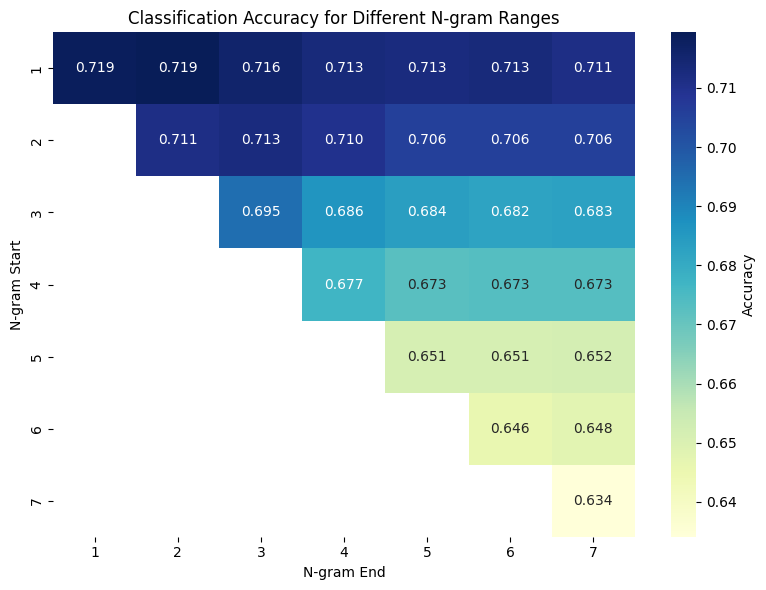

In [4]:
# (iii) Create accuracy heatmap
acc_df = pd.DataFrame(accuracy_matrix, 
                      index=range(1, n_max + 1), 
                      columns=range(1, n_max + 1))
acc_df = acc_df.replace(0, np.nan)

plt.figure(figsize=(8, 6))
sns.heatmap(acc_df, annot=True, fmt=".3f", cmap="YlGnBu", cbar_kws={"label": "Accuracy"})
plt.xlabel("N-gram End")
plt.ylabel("N-gram Start")
plt.title("Classification Accuracy for Different N-gram Ranges")
plt.tight_layout()
plt.show()

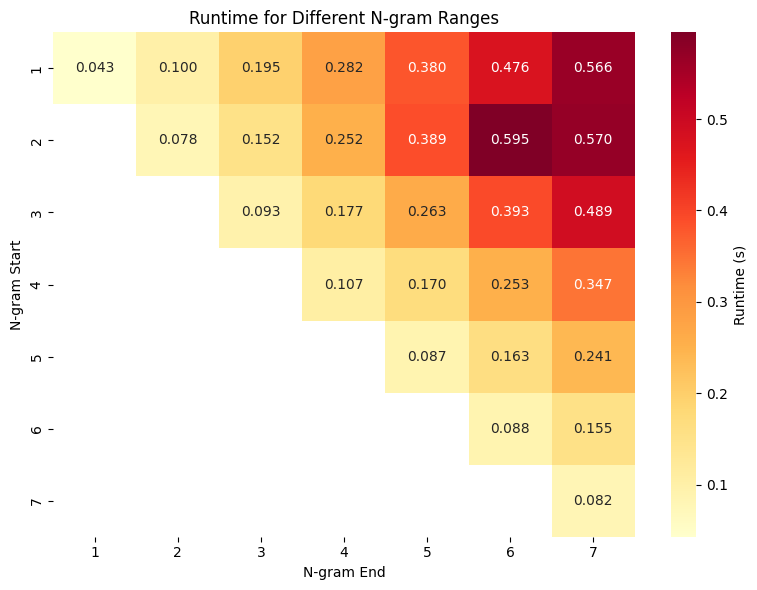

In [5]:
# (iii) Create runtime heatmap
time_df = pd.DataFrame(runtime_matrix, 
                       index=range(1, n_max + 1), 
                       columns=range(1, n_max + 1))
time_df = time_df.replace(0, np.nan)

plt.figure(figsize=(8, 6))
sns.heatmap(time_df, annot=True, fmt=".3f", cmap="YlOrRd", cbar_kws={"label": "Runtime (s)"})
plt.xlabel("N-gram End")
plt.ylabel("N-gram Start")
plt.title("Runtime for Different N-gram Ranges")
plt.tight_layout()
plt.show()